# Mall_Customers

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Admin\hipython\data\Mall_Customers.csv')
print(df.head())
print(df.shape)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


In [4]:
# CustomerID 제거, 성별 인코딩
df['Gender'] = (df['Gender'] == 'Male').astype(int)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].values


# StandardScaler로 x 스케일링


In [5]:
# StandardScaler로 x 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA : 2개의 주성분으로 압축

In [6]:
# PCA : 2개의 주성분으로 압축
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"누적 설명 분산: {sum(pca.explained_variance_ratio_):.4f}")

설명된 분산 비율: [0.33690046 0.26230645]
누적 설명 분산: 0.5992


# KMEANS 클러스터링 


In [7]:
# KMEANS 클러스터링
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)
print(f"클러스터 레이블: {np.unique(labels)}")
print(f"각 클러스터 샘플 수: {np.bincount(labels)}")

클러스터 레이블: [0 1 2 3 4]
각 클러스터 샘플 수: [48 43 26 34 49]


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# KMeans 클러스터링 결과 시각화

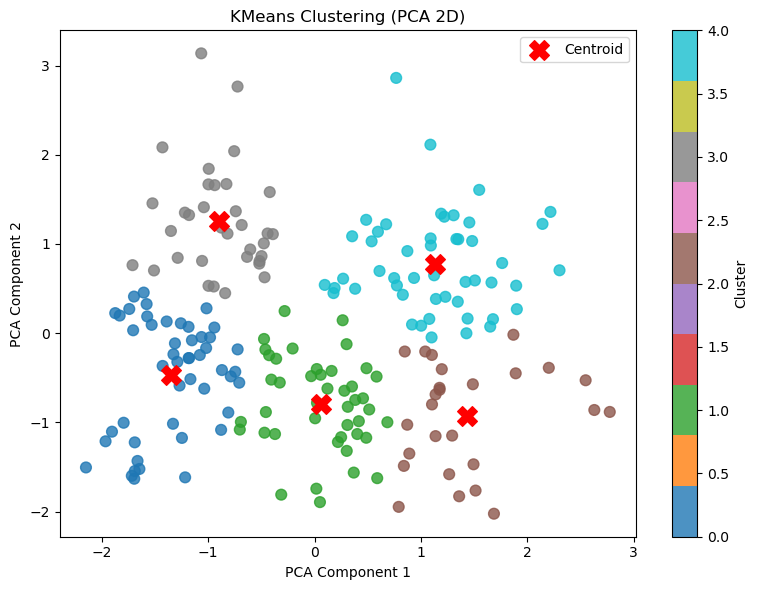

In [8]:
# KMeans 클러스터링 결과 시각화
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=60, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.title('KMeans Clustering (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# 1. ID 제거

In [ ]:
cust_df = cust_df.drop('CustomerID', axis=1)

In [ ]:
# 2. Gender 인코딩

In [ ]:
cust_df['Gender'] = cust_df['Gender'].map({'Male':0, 'Female':1})

In [ ]:
# 3. 피처 분리

In [ ]:
X = cust_df[['Gender', 'Age',
             'Annual Income (k$)',
             'Spending Score(1-100)']]

In [ ]:
# 4. 스케일링

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)